# Proyek Analisis Data: [Bike-Sharing-Dataset]
- **Nama:** [Dini Sahfitri]
- **Email:** [dinisahfitriiiii@gmail.com]
- **ID Dicoding:** [dinisahfitri]

## Menentukan Pertanyaan Bisnis

- **Pertanyaan 1:** Faktor apa saja (cuaca, musim, jam, dan hari kerja) yang paling berpengaruh terhadap jumlah penyewaan sepeda (cnt) pada tahun 2011–2012?
- **Pertanyaan 2:** Berapa persentase peningkatan jumlah penyewaan sepeda pada bulan dengan jumlah tertinggi dibandingkan rata-rata bulanan pada tahun 2012?
- **Pertanyaan 3:** Apakah variabel cuaca (weathersit) memiliki pengaruh yang lebih besar dibandingkan status hari libur (holiday) terhadap jumlah penyewaan?
- **Pertanyaan 4:** Musim mana yang memiliki rata-rata penyewaan sepeda (cnt) terendah dan seberapa besar perbedaannya dibanding musim lainnya?

## Import Semua Packages/Library yang Digunakan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

#### Load df Bike-Sharing-Dataset(day dataset dan hour dataset)

In [2]:
day_df = pd.read_csv('data/day.csv')

day_df


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,727,2012-12-27,1,1,12,0,4,1,2,0.254167,0.226642,0.652917,0.350133,247,1867,2114
727,728,2012-12-28,1,1,12,0,5,1,2,0.253333,0.255046,0.590000,0.155471,644,2451,3095
728,729,2012-12-29,1,1,12,0,6,0,2,0.253333,0.242400,0.752917,0.124383,159,1182,1341
729,730,2012-12-30,1,1,12,0,0,0,1,0.255833,0.231700,0.483333,0.350754,364,1432,1796


In [3]:
hour_df = pd.read_csv('data/hour.csv')
hour_df

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,17375,2012-12-31,1,1,12,19,0,1,1,2,0.26,0.2576,0.60,0.1642,11,108,119
17375,17376,2012-12-31,1,1,12,20,0,1,1,2,0.26,0.2576,0.60,0.1642,8,81,89
17376,17377,2012-12-31,1,1,12,21,0,1,1,1,0.26,0.2576,0.60,0.1642,7,83,90
17377,17378,2012-12-31,1,1,12,22,0,1,1,1,0.26,0.2727,0.56,0.1343,13,48,61


**Insight:** (Opsional)
- Dataset day berisi 731 baris dan 16  kolom (instant, dteday, season, yr, mnth, holiday, weekday, workingday, weathersit, temp, atemp, hum	windspeed, casual, registered,dan cnt)
- Dataset Hour berisi 17379 baris dan 17 kolom (instant, dteday, season, yr, mnth, hr, holiday, weekday, workingday, weathersit, temp, atemp, hum	windspeed, casual, registered, cnt

### Assessing Data

#### Identifying Bike-Sharing-Dataset problem

- ***Pemeriksaan Tipe Data*** 

In [4]:
#Cek tipe data
print("Info day_df:")
print(day_df.info())

print("\nInfo hour_df:")
print(hour_df.info())

#Cek missing value
print("\n\nMissing Values - DAY")
print(day_df.isnull().sum())
print("\nMissing Values - HOUR")
print(hour_df.isnull().sum())

#cek duplikasi data
print("\n\nDuplicate DAY:", day_df.duplicated().sum())
print("\nDuplicate HOUR:", hour_df.duplicated().sum())

#cek invalid value
print("\n\nDescribe DAY:")
print(day_df.describe())
print("\nDescribe HOUR:")
print(hour_df.describe())

# cek konsistensi data

#cek konsistensi nilai casual+registered=count(cnt) 
print("\n\n Consistent DAY",(day_df['casual'] + day_df['registered'] == day_df['cnt']).value_counts())

#cek konsistensi nilai casual+registered=count(cnt)
print("\n  Consistent HOUR",(day_df['casual'] + day_df['registered'] == day_df['cnt']).value_counts())

#cek konsistensi data count(cnt) pada data day_df = count(cnt) pada data hour_df berdasarkan date(dteday)
# agregasi hour ke daily
hour_agg = hour_df.groupby('dteday')['cnt'].sum().reset_index()
# gabungkan dengan day
compare = pd.merge(day_df[['dteday','cnt']], hour_agg, on='dteday', suffixes=('_day','_hour'))
# cek apakah sama
compare['equal'] = compare['cnt_day'] == compare['cnt_hour']
print("\n",compare['equal'].value_counts())


Info day_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB
None

Info hour_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entr

**Steps to Take:**
- Pemeriksaan tipe data
- Cek missing value
- Cek duplikasi data
- Cek parameter statistik dari kolom numerik data(Invalid Value)
- Cek konsistensi data
  - cek apakah value registered + casual = count(cnt) pada day_df
  - cek apakah value registered + casual = count(cnt) pada hour_df
  - cek apakah count(cnt) day_df = count(cnt) hour_df berdasarkan date(dteday) day_df

**Insight:** (Opsional)
- Tipe Data : Kolom dteday pada kedua dataset masih bertipe object dan perlu dikonversi menjadi tipe datetime untuk analisis berbasis waktu.
- Missing Value : Tidak ditemukan missing value pada seluruh kolom di dataset day maupun hour, sehingga tidak diperlukan penanganan missing value.
- Duplicate Data : Tidak ditemukan data duplikat pada kedua dataset, sehingga data sudah valid.
- Invalid Value (Statistik Data): Berdasarkan statistik deskriptif, tidak ditemukan nilai yang tidak wajar (nilai penyewa selalu bernilai positif), nilai pada fitur numerik seperti temp, hum, dan windspeed berada dalam rentang normal (0–1). Namun, penamaan nama kolom seperti cnt, yr masih perlu diperjelas.
- Konsistensi Data :
  - Nilai cnt konsisten dengan penjumlahan casual + registered pada dataset day maupun dataset hour
  - Hasil agregasi jumlah penyewaan dari dataset hour per hari konsisten dengan dataset day.
  Hal ini menunjukkan tidak terdapat inkonsistensi antar variabel maupun antar dataset.

### Cleaning Data

#### Fixing Bike-Sharing-Dataset problem
- Tidak ditemukan missing value sehingga tidak diperlukan penanganan missing value
- Tidak ditemukan duplikat data pada kedua dataset, sehingga tidak perlu menghapus duplikasi.
- Tidak ada inkonsistensi data berdasarkan data yang telah antara jumlah penyewa regular+casual dengan jumlah countnya sehingga tidak perlu penangan inkonsistensi data.
- Tidak ditemukan inacurate value, seperti kolom weekday (sudah benar ada di rentang 1-6), kolom  temp, atemp, hum, windspeed (sudah benar ada di rrentang (0-1)

 
  Hal-Hal yang harus diperbaiki:
  
1. Tipe data kolom dteday perlu dikonversi menjadi tipe datetime untuk analisis berbasis waktu.
2. Nama kolom yang berupa singkatan diperbaiki agar lebih jelas dan dapat dipahami.
3. Mapping data kategorikal dengan deskripsi kategorinya agar lebih jelas.

In [5]:
# mengubah tipe data object menjadi datetime kolom dteday pada dataset day dan dataset hour
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

# mengganti nama kolom pada dataset day
day_df = day_df.rename(columns={
    'dteday': 'date',
    'yr': 'year',
    'mnth': 'month',
    'cnt': 'total_rentals',
    'hum': 'humidity',
    'weathersit': 'weather_condition'
})

# Mengganti nama kolom pada dataset hour
hour_df = hour_df.rename(columns={
    'dteday': 'date',
    'yr': 'year',
    'mnth': 'month',
    'hr': 'hour',
    'cnt': 'total_rentals',
    'hum': 'humidity',
    'weathersit': 'weather_condition'
})

# mapping season kategori (season,year,weather condition) sesuai namanya agar lebih mudah dipahami
season_map = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
year_map = {0: 2011, 1: 2012}
weather_map = {
    1: 'Clear',
    2: 'Mist',
    3: 'Light Rain',
    4: 'Heavy Rain/Snow'
}

for df in [day_df, hour_df]:
    df['season'] = df['season'].map(season_map)
    df['year'] = df['year'].map(year_map)
    df['weather_condition'] = df['weather_condition'].map(weather_map)


# Cek kembali setelah dilakukan cleaning

# Cek tipe data dan penamaan kolom
print("Info day_df:")
print(day_df.info())
print("\nInfo hour_df:")
print(hour_df.info())

# Cek hasil mapping kolom kategori
day_df['season'].unique()
day_df['weather_condition'].unique()
hour_df['season'].unique()
hour_df['weather_condition'].unique()


Info day_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   instant            731 non-null    int64         
 1   date               731 non-null    datetime64[ns]
 2   season             731 non-null    object        
 3   year               731 non-null    int64         
 4   month              731 non-null    int64         
 5   holiday            731 non-null    int64         
 6   weekday            731 non-null    int64         
 7   workingday         731 non-null    int64         
 8   weather_condition  731 non-null    object        
 9   temp               731 non-null    float64       
 10  atemp              731 non-null    float64       
 11  humidity           731 non-null    float64       
 12  windspeed          731 non-null    float64       
 13  casual             731 non-null    int64         
 1

array(['Clear', 'Mist', 'Light Rain', 'Heavy Rain/Snow'], dtype=object)

**Insight:** (Opsional)
- Dilakukan konversi tipe data pada kolom dteday menjadi format datetime
- Dilakukan penyesuaian nama kolom menjadi lebih deskriptif, seperti cnt menjadi total_rentals dan weathersit menjadi weather_condition
- Dilakukan transformasi fitur kategorikal (season, year, dan weather_condition) dari bentuk numerik menjadi label agar lebih mudah dipahami
- Dataset telah bersih, konsisten, dan siap digunakan untuk tahap analisis lebih lanjut

## Exploratory Data Analysis (EDA)

### Explore Dataset Bike Sharing

In [6]:
print(" Deskripsi Data Day ")
print(day_df.describe(include="all"))

print("\nDeskripsi Data Hour ")
print(hour_df.describe(include="all"))

# Cek total penyewaan berdasarkan season
print("Rental berdasarkan Season ")
print(day_df.groupby(by="season")["total_rentals"].agg([
    "count", "mean", "min", "max"
]).sort_values(by="mean", ascending=False))

# Cek total penyewaan berdasarkan weather
print("\n Rental berdasarkan Weather ")
print(day_df.groupby(by="weather_condition")["total_rentals"].agg([
    "count", "mean", "min", "max"
]).sort_values(by="mean", ascending=False))

# Cek total penyewaan berdasarkan month
print("\nRental berdasarkan Month ")
print(day_df.groupby(by="month")["total_rentals"].agg([
    "mean", "min", "max"
]).sort_values(by="month"))

# Cek total penyewaan berdasarkan holiday vs bukan holiday
print("\nRental: Holiday vs Non-Holiday ")
print(day_df.groupby(by="holiday")["total_rentals"].agg([
    "mean", "min", "max"
]))

# Cek total penyewaan berdasarkan jam
print("\nRental berdasarkan Jam ")
print(hour_df.groupby(by="hour")["total_rentals"].agg([
    "mean", "min", "max"
]).sort_values(by="mean", ascending=False))

# Cek total penyewaan berdasarkan pola harian
print("\nPola Harian (Weekday) ")
print(day_df.groupby(by="weekday")["total_rentals"].mean())

# Perbandingan casual dan registered berdasarkan season
print("\nCasual vs Registered per Season ")
print(day_df.groupby("season")[["casual","registered"]].mean())

 Deskripsi Data Day 
           instant                 date season         year       month  \
count   731.000000                  731    731   731.000000  731.000000   
unique         NaN                  NaN      4          NaN         NaN   
top            NaN                  NaN   Fall          NaN         NaN   
freq           NaN                  NaN    188          NaN         NaN   
mean    366.000000  2012-01-01 00:00:00    NaN  2011.500684    6.519836   
min       1.000000  2011-01-01 00:00:00    NaN  2011.000000    1.000000   
25%     183.500000  2011-07-02 12:00:00    NaN  2011.000000    4.000000   
50%     366.000000  2012-01-01 00:00:00    NaN  2012.000000    7.000000   
75%     548.500000  2012-07-01 12:00:00    NaN  2012.000000   10.000000   
max     731.000000  2012-12-31 00:00:00    NaN  2012.000000   12.000000   
std     211.165812                  NaN    NaN     0.500342    3.451913   

           holiday     weekday  workingday weather_condition        temp  \
co

**Insight:** (Opsional)
- Dataset terdiri dari data penyewaan sepeda dalam dua bentuk, yaitu data harian dan data per jam
- Variabel dalam dataset mencakup faktor waktu(hour, weekday/weekend, holiday, month, year) , kondisi cuaca(weather_condition, temp, atemp, humidity, windspeed , serta jumlah penyewaan sepeda(casual, register, dan total)
- Rata-rata penyewaan harian sekitar 4.5K dengan variasi cukup besar (min 22, max 8714), menunjukkan fluktuasi tinggi.
- Musim paling tinggi adalah Fall (~5644), sedangkan terendah Spring (~2604) dengan selisih yang cukup besar.
- Cuaca sangat berpengaruh: Clear tertinggi (~4876), turun di Mist (~4035), dan jauh lebih rendah saat Light Rain (~1803).
- Tren bulanan meningkat dari awal tahun, puncak sekitar Juni–September (~5700), lalu menurun di akhir tahun.
- Hari libur memiliki rata-rata lebih rendah (~3735) dibanding hari biasa (~4527).
- Jam sibuk terjadi pada sore (17–18) dan pagi (08), menunjukkan pola saat jam berangkat dan pulang kerja.
- Perbedaan antar weekday tidak terlalu signifikan, tetapi cenderung sedikit lebih tinggi di akhir minggu.
- Pengguna registered jauh lebih dominan dibanding casual di semua musim.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Faktor apa saja yang paling berpengaruh (cuaca, musim, jam, hari kerja) terhadap jumlah penyewaan sepeda(cnt) pada tahun 2011–2012??

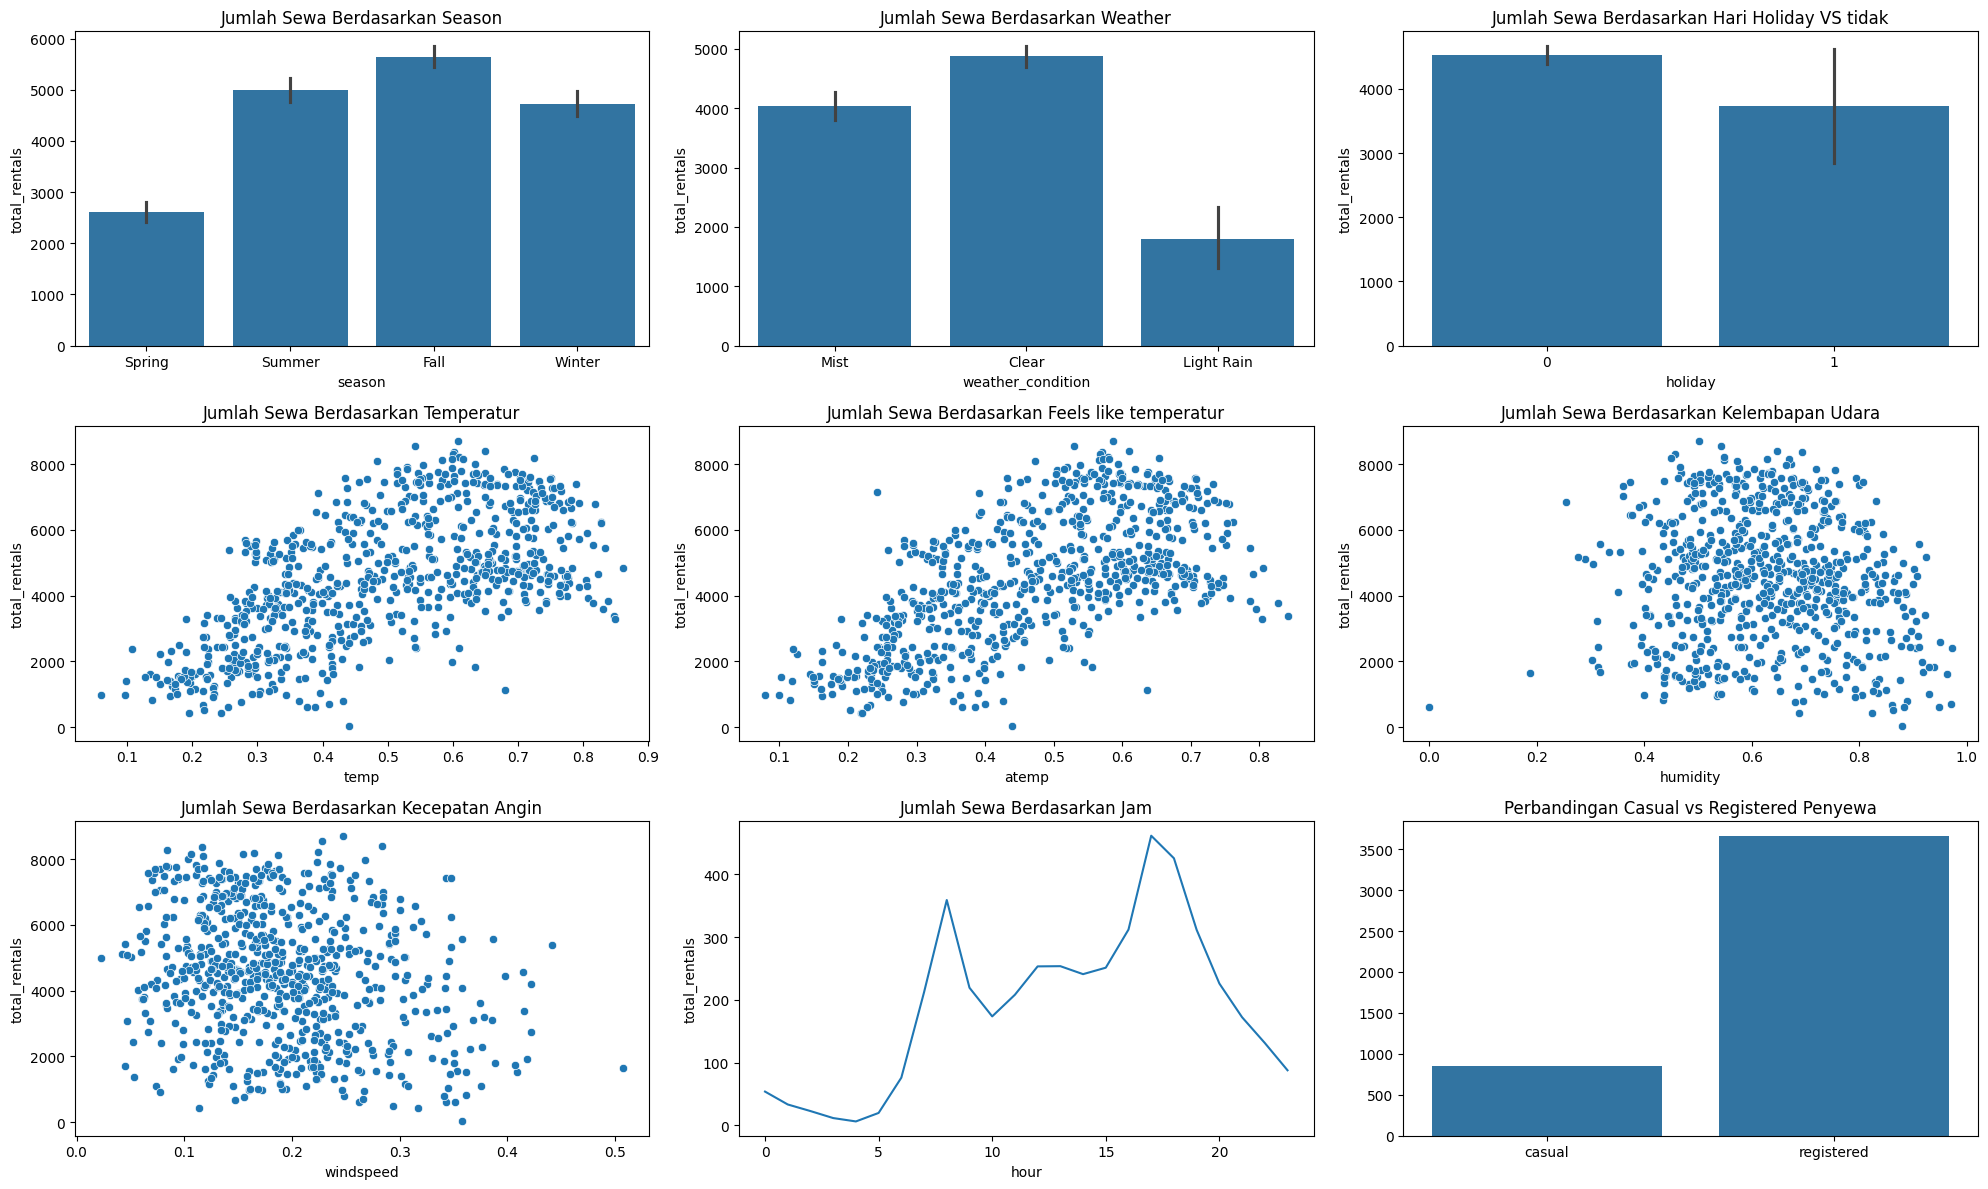

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20, 12))

# 1. Season
plt.subplot(3,3,1)
sns.barplot(data=day_df, x="season", y="total_rentals")
plt.title("Jumlah Sewa Berdasarkan Season")

# 2. Weather
plt.subplot(3,3,2)
sns.barplot(data=day_df, x="weather_condition", y="total_rentals")
plt.title("Jumlah Sewa Berdasarkan Weather")

# 4. Holiday 
plt.subplot(3,3,3)
sns.barplot(data=day_df, x="holiday", y="total_rentals")
plt.title("Jumlah Sewa Berdasarkan Hari Holiday VS tidak")

# 5. Temperature
plt.subplot(3,3,4)
sns.scatterplot(data=day_df, x="temp", y="total_rentals")
plt.title("Jumlah Sewa Berdasarkan Temperatur")

# 6. Feels like temp
plt.subplot(3,3,5)
sns.scatterplot(data=day_df, x="atemp", y="total_rentals")
plt.title("Jumlah Sewa Berdasarkan Feels like temperatur")

# 7. Humidity
plt.subplot(3,3,6)
sns.scatterplot(data=day_df, x="humidity", y="total_rentals")
plt.title("Jumlah Sewa Berdasarkan Kelembapan Udara")

# 8. Windspeed
plt.subplot(3,3,7)
sns.scatterplot(data=day_df, x="windspeed", y="total_rentals")
plt.title("Jumlah Sewa Berdasarkan Kecepatan Angin")

# 9. Hourly pattern
plt.subplot(3,3,8)
sns.lineplot(data=hour_df.groupby("hour")["total_rentals"].mean())
plt.title("Jumlah Sewa Berdasarkan Jam")

# 11. Casual vs Registered (total insight)
plt.subplot(3,3,9)
sns.barplot(data=day_df[["casual","registered"]].mean())
plt.title("Perbandingan Casual vs Registered Penyewa")

plt.tight_layout()
plt.show()

### Pertanyaan 2:  Berapa persentase peningkatan jumlah penyewaan sepeda pada bulan dengan jumlah tertinggi dibandingkan rata-rata bulanan pada tahun 2012?

Peningkatan: 30.20%


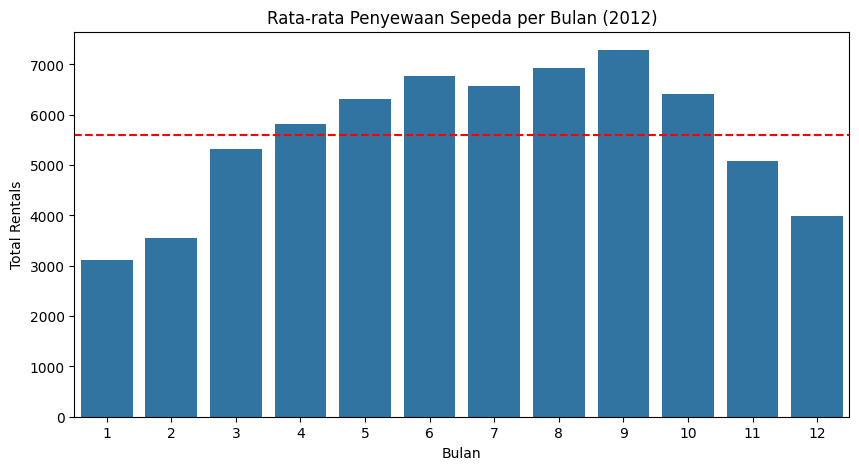

In [8]:
df_2012 = day_df[day_df["year"] == 2012]

# Rata-rata penyewaan per bulan
monthly = df_2012.groupby("month")["total_rentals"].mean().reset_index()

# Hitung nilai penting
max_value = monthly["total_rentals"].max()
avg_value = monthly["total_rentals"].mean()
increase_pct = ((max_value - avg_value) / avg_value) * 100

print(f"Peningkatan: {increase_pct:.2f}%")

# Visualisasi
plt.figure(figsize=(10,5))
sns.barplot(data=monthly, x="month", y="total_rentals")

# Garis rata-rata
plt.axhline(avg_value, linestyle='--', color='red')

plt.title("Rata-rata Penyewaan Sepeda per Bulan (2012)")
plt.xlabel("Bulan")
plt.ylabel("Total Rentals")

plt.show()

### Pertanyaan 3: Apakah variabel cuaca (weathersit) memiliki pengaruh yang lebih besar dibandingkan status hari libur (holiday) terhadap jumlah penyewaan?

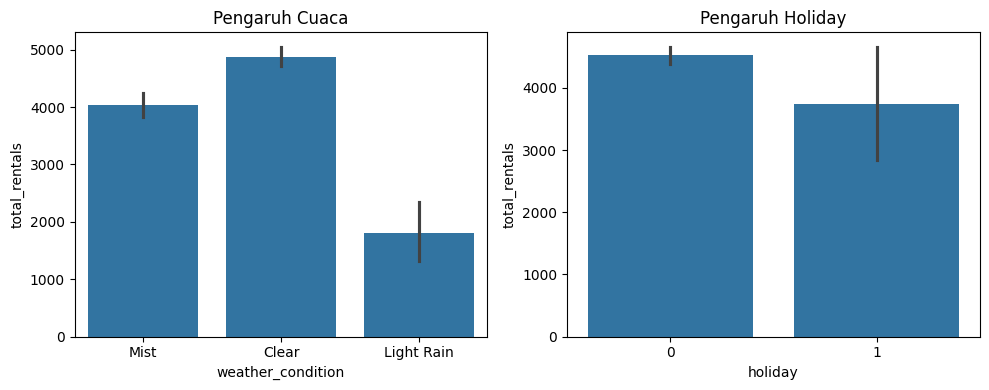

Weather range :  3073.5004628201173  , Holiday range:  792.1042253521127


In [9]:
plt.figure(figsize=(10,4))  # atur ukuran tampilan

# Visualisasi pengaruh cuaca terhadap jumlah penyewaan
plt.subplot(1,2,1)
sns.barplot(data=day_df, x="weather_condition", y="total_rentals")
plt.title("Pengaruh Cuaca")

# Visualisasi pengaruh hari libur terhadap jumlah penyewaan
plt.subplot(1,2,2)
sns.barplot(data=day_df, x="holiday", y="total_rentals")
plt.title("Pengaruh Holiday")

plt.tight_layout()
plt.show()

# Menghitung range (selisih max-min) rata-rata penyewaan berdasarkan cuaca
weather_range = day_df.groupby("weather_condition")["total_rentals"].mean().max() - \
                day_df.groupby("weather_condition")["total_rentals"].mean().min()

# Menghitung range rata-rata penyewaan berdasarkan status holiday
holiday_range = day_df.groupby("holiday")["total_rentals"].mean().max() - \
                day_df.groupby("holiday")["total_rentals"].mean().min()

# Membandingkan seberapa besar pengaruh cuaca vs holiday
print("Weather range : ", weather_range, " , Holiday range: ", holiday_range)

### Pertanyaan 4: Musim mana yang memiliki rata-rata penyewaan sepeda (cnt) terendah dan seberapa besar perbedaannya dibanding musim lainnya?

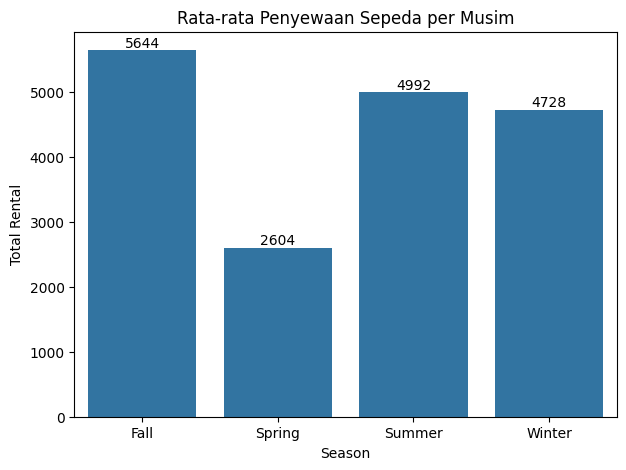

In [10]:
# Hitung rata-rata penyewaan per musim
season_avg = day_df.groupby("season")["total_rentals"].mean().reset_index()

plt.figure(figsize=(7,5))  # atur ukuran plot
ax = sns.barplot(
    data=season_avg,
    x="season",
    y="total_rentals"
)

# label angka di atas bar
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.0f}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom'
    )

plt.title("Rata-rata Penyewaan Sepeda per Musim")
plt.xlabel("Season")
plt.ylabel("Total Rental")

plt.show()

**Insight:** (Opsional)
- Pertanyaan 1 : Faktor apa saja yang paling berpengaruh (cuaca, musim, jam, hari kerja)?
  - Jam (hour) → paling dominan. Ada pola jelas: puncak di jam berangkat & pulang kerja (sekitar 8 pagi & 17–18 sore).
  - Musim (season) → berpengaruh besar. Tertinggi di Fall, terendah di Spring.
  - Cuaca (weather) → signifikan. Clear jauh lebih tinggi, Light Rain turun drastis.
  - Hari kerja vs libur → ada pengaruh, tapi tidak sebesar jam & cuaca. Hari non-libur cenderung lebih tinggi.
- Pertanyaan 2 : Berapa persentase peningkatan jumlah penyewaan sepeda pada bulan dengan jumlah tertinggi dibandingkan rata-rata bulanan pada tahun 2012?
  - Bulan tertinggi: sekitar September (7300)
  - Rata-rata bulanan: sekitar 5600
  - Peningkatan ≈ 30% dibandingkan rata rata tiap bulan
  - ada lonjakan signifikan di bulan puncak, kemungkinan karena kombinasi musim nyaman + aktivitas tinggi.
- Pertanyaan 3: Apakah variabel cuaca (weathersit) memiliki pengaruh yang lebih besar dibandingkan status hari libur (holiday) terhadap jumlah penyewaan?
  - Range pengaruh: Cuaca ≈ 3073, Holiday ≈ 792
  - orang tetap sewa sepeda walau bukan hari libur, tapi sangat mempertimbangkan kondisi cuaca. Artinya cuaca jauh lebih berpengaruh dibanding status hari libur.
- Pertanyaan 4: Musim mana yang memiliki rata-rata penyewaan sepeda (cnt) terendah dan seberapa besar perbedaannya dibanding musim lainnya?
  - Penyewaan sepeda yang paling rendah terjadi pada musim semi(spring), jauh lebih rendah dibanding musim lain.

## Analisis Lanjutan (Opsional)

1. Segmentasi berdasarkan tingkat permintaan.
- Pendekatan yang digunakan adalah binning dan rule-based grouping untuk mengelompokkan data berdasarkan tingkat permintaan, waktu, serta kondisi lingkungan seperti musim dan cuaca. Tujuannya adalah untuk mengidentifikasi pola perilaku pengguna dalam menyewa sepeda berdasarkan berbagai kondisi.

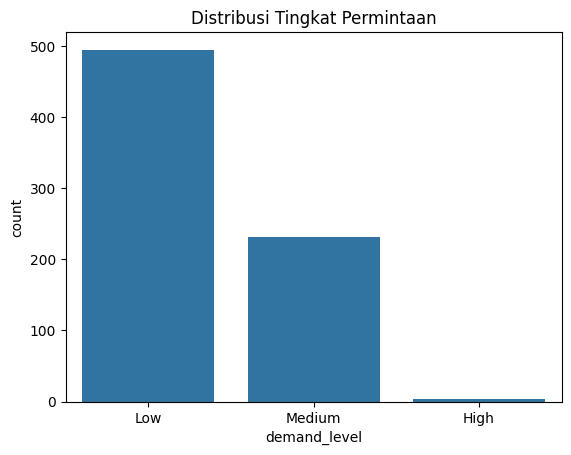

In [11]:
# Membuat kategori tingkat permintaan
def categorize_cnt(cnt):
    if cnt < df['total_rentals'].quantile(0.33):
        return "Low"
    elif cnt < df['total_rentals'].quantile(0.66):
        return "Medium"
    else:
        return "High"

day_df['demand_level'] = df['total_rentals'].apply(categorize_cnt)

# Cek distribusi
day_df['demand_level'].value_counts()

sns.countplot(data=day_df, x='demand_level')
plt.title("Distribusi Tingkat Permintaan")
plt.show()

Distribusi tingkat permintaan menunjukkan bahwa kategori permintaan tinggi sangat jarang terjadi, sementara sebagian besar penyewaan berada pada tingkat rendah hingga sedang.

2. Clustering pola waktu

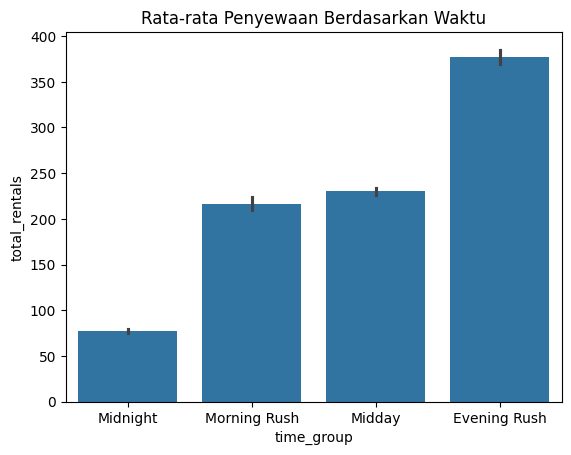

In [12]:
def time_group(hour):
    if 6 <= hour < 10:
        return "Morning Rush"
    elif 10 <= hour < 16:
        return "Midday"
    elif 16 <= hour < 20:
        return "Evening Rush"
    else:
        return "Midnight"

hour_df['time_group'] = hour_df['hour'].apply(time_group)

hour_df.groupby('time_group')['total_rentals'].mean().sort_values()

sns.barplot(data=hour_df, x='time_group', y='total_rentals')
plt.title("Rata-rata Penyewaan Berdasarkan Waktu")
plt.show()

### Insight:
- Ada pola commuting kuat. Sistem bike sharing berfungsi sebagai transportasi pendukung (last-mile transport)
- Evening > Morning → kemungkinan:orang lebih fleksibel saat pulang (lebih banyak aktivitas setelah kerja)

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:**
Faktor yang paling berpengaruh terhadap jumlah penyewaan sepeda adalah jam (hour) sebagai faktor dominan, diikuti oleh musim (season) dan cuaca (weather). Sementara itu, status hari kerja/libur memiliki pengaruh, namun tidak sebesar faktor lainnya.

- **Conclusion pertanyaan 2:**
Terdapat peningkatan sekitar **30%** pada bulan dengan jumlah penyewaan tertinggi dibandingkan rata-rata bulanan tahun 2012, yang menunjukkan adanya lonjakan signifikan pada periode tertentu.

- **Conclusion pertanyaan 3:**
Variabel cuaca (weather) memiliki pengaruh yang jauh lebih besar dibandingkan status hari libur (holiday) terhadap jumlah penyewaan sepeda.

- **Conclusion pertanyaan 4:**
Musim dengan rata-rata penyewaan terendah adalah **Spring**, dengan jumlah yang secara signifikan lebih rendah dibandingkan musim lainnya.

**Rekomendasi Action Item:**
- Fokuskan penyediaan sepeda pada **jam sibuk (pagi pukul 8 & sore pukul 17-18 )** untuk mengakomodasi permintaan tinggi.
- Tingkatkan kapasitas dan kesiapan operasional pada **bulan pertengahan (mei hingga oktober) dan musim (fall dan summer)** dengan permintaan tinggi.
- Pertimbangkan faktor **cuaca** dalam perencanaan, misalnya dengan mengetahui prediksi cuaca lebih awal agar dapat mengatur persediaan sepeda (saat cuaca diprediksi cerah, stok sepeda dapat disediakan lebih banyak).
- Atur jumlah dan penyebaran sepeda sesuai pola tingkat permintaan agar tidak berlebihan atau kekurangan.
- Perbandingan tingkat penyewa registered jauh lebih besar dibanding penyewa casual, sehingga penyediaan stok tambahan untuk penyewa casual tidak perlu menjadi prioritas utama dan dapat difokuskan lebih banyak pada kebutuhan penyewa registered.

In [13]:
hour_df.to_csv("main_data.csv", index=False)